# Midterm Project: Network Simulation and Predictive Optimization

**Monica Joya - ITAI 4370 - Midterm**

## Overview

In this midterm I used the provided starter code to study a network three ways. Part 1 is a discrete-event simulation that follows packets through a chain of three routers and measures their latency and the network's throughput. Part 2 is an agent-based model where each router acts on its own and reroutes traffic to its neighbors when it gets congested. Part 3 uses machine learning to forecast traffic and then uses that forecast to route flows to the quieter path. The three parts share one theme: how traffic moves through a network, and how a network can manage its own load.

**Data:** Each part makes its own synthetic data. Part 1 releases packets over time, Part 2 places routers on a small mesh, and Part 3 generates hourly traffic with a daily cycle, a slow trend, and noise.

**Note on the Mesa code (Part 2):** The starter code used the older Mesa scheduler (mesa.time.RandomActivation), which was removed in Mesa 3, so I moved it to the current approach where the model tells its agents to act with self.agents.shuffle_do. The starter also only printed a message when a router was overloaded but never actually moved any traffic, so I connected that step so a congested router hands its excess load to neighbors that still have room. Those are the only changes to the provided logic, and the rest is the starter code as given.

**Note on the prediction (Part 3):** The model's features are all past values of the traffic, so it never sees the value it is trying to predict. This keeps the result honest and avoids the target leakage I ran into in Lab 04.

## Part 1: Network Traffic Simulation with SimPy

**Objective:** simulate three routers connected in a chain, where each router processes a packet and forwards it to the next, then measure the latency of each packet and the throughput of the network.

SimPy is a discrete-event simulator, so time jumps from one event to the next rather than ticking evenly. Each router has capacity for one packet at a time, so when packets arrive faster than a router can clear them, they queue, and that waiting is what turns into latency. I kept the starter code and added the timing collection so latency and throughput can be measured.

Packets completed : 10
Ideal latency     : 6 time units (a packet that never waits)
Average latency   : 8.10 time units
Min / Max latency : 6 / 10 time units
Throughput        : 0.417 packets per time unit


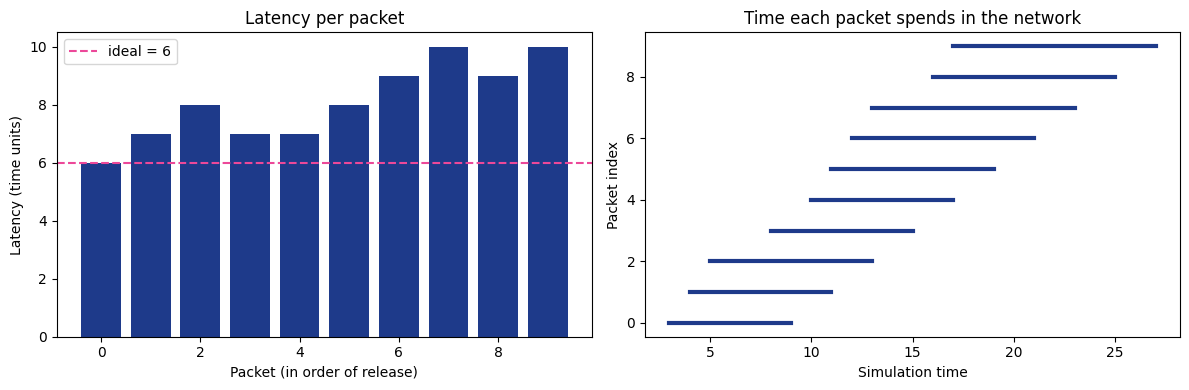

In [1]:
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt
import warnings
%matplotlib inline
warnings.filterwarnings("ignore")   # keep the notebook output clean

# Simulation parameters (from the starter code)
RANDOM_SEED = 42
NUM_PACKETS = 10
PROC_DELAY  = 2      # processing time per router, in time units
NUM_ROUTERS = 3
random.seed(RANDOM_SEED)

records = []          # I record each packet's timing to measure latency and throughput

def packet(env, name, routers):
    """One packet travels the chain, waiting for and being served by each router in turn."""
    start = env.now
    for r in routers:
        with r.request() as req:
            yield req                       # wait until this router is free
            yield env.timeout(PROC_DELAY)   # processing time at this router
    end = env.now
    records.append({"packet": name, "generated": start,
                    "completed": end, "latency": end - start})

def packet_generator(env, routers):
    """Release packets over time, one every 1 to 3 time units."""
    for i in range(NUM_PACKETS):
        yield env.timeout(random.randint(1, 3))
        env.process(packet(env, f"Packet_{i}", routers))

# Build and run the simulation
env = simpy.Environment()
routers = [simpy.Resource(env, capacity=1) for _ in range(NUM_ROUTERS)]
for i, r in enumerate(routers):
    r.name = f"Router_{i+1}"
env.process(packet_generator(env, routers))
env.run()

# Measure latency and throughput
latencies  = [r["latency"] for r in records]
first_in   = min(r["generated"] for r in records)
last_out   = max(r["completed"] for r in records)
throughput = len(records) / (last_out - first_in)
ideal_latency = NUM_ROUTERS * PROC_DELAY

print(f"Packets completed : {len(records)}")
print(f"Ideal latency     : {ideal_latency} time units (a packet that never waits)")
print(f"Average latency   : {np.mean(latencies):.2f} time units")
print(f"Min / Max latency : {min(latencies)} / {max(latencies)} time units")
print(f"Throughput        : {throughput:.3f} packets per time unit")

# Plot latency per packet and each packet's time in the network
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(range(len(records)), latencies, color="#1e3a8a")
ax[0].axhline(ideal_latency, color="#ec4899", linestyle="--", label=f"ideal = {ideal_latency}")
ax[0].set_title("Latency per packet")
ax[0].set_xlabel("Packet (in order of release)")
ax[0].set_ylabel("Latency (time units)")
ax[0].legend()
for i, r in enumerate(records):
    ax[1].plot([r["generated"], r["completed"]], [i, i], color="#1e3a8a", linewidth=3)
ax[1].set_title("Time each packet spends in the network")
ax[1].set_xlabel("Simulation time")
ax[1].set_ylabel("Packet index")
plt.tight_layout()
plt.show()

**What this shows.** The first packets pass through close to the ideal latency, but later ones wait longer because the single-capacity routers are still busy with earlier packets. That growing wait is queueing, and it is exactly what a discrete-event simulation is good at exposing. The throughput figure says how many packets the whole chain clears per unit of time, which is the network's real capacity once the queueing is taken into account. This connects directly to the outcomes for this part: discrete-event simulation for networking, and measuring latency and throughput in that simulated environment.

## Part 2: Agent-Based Network Modeling with Mesa

**Objective:** model a small network where each router is its own agent. Routers carry a traffic load, and when a router becomes congested it reroutes traffic to neighbors that still have room. The goal is to watch congestion build and then recover.

Two notes on the starter code. First, it used the older Mesa scheduler (`mesa.time.RandomActivation`), which was removed in Mesa 3, so I moved it to the current approach where the model tells its agents to act with `self.agents.shuffle_do("step")`. Second, the starter only printed a message when a router was overloaded but never actually rerouted anything, so I made the rerouting real: a congested router moves its excess load to neighbors with spare capacity. That change is what makes the recovery in the chart genuine.

Steps run         : 30
Routers           : 10
Congestion events : 9
Reroute actions   : 9


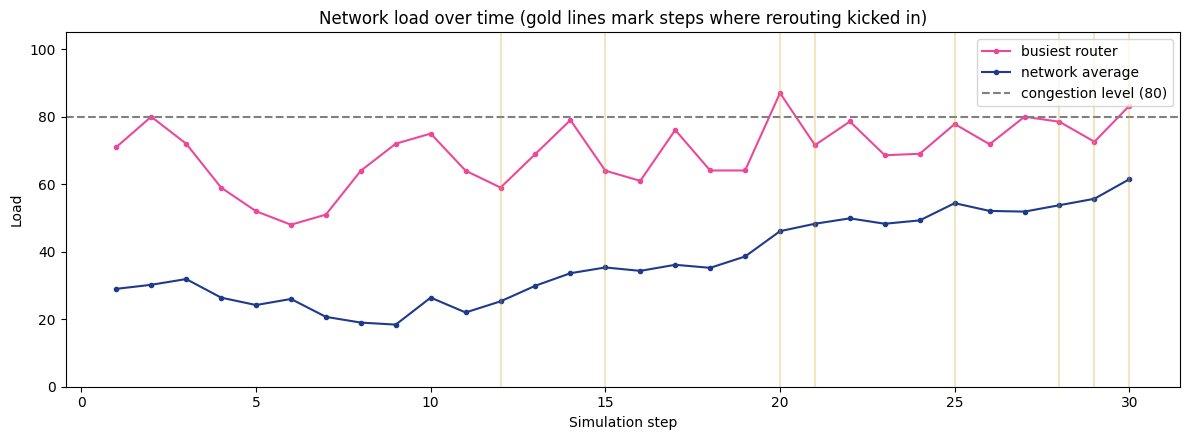

In [2]:
import mesa
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from mesa import Agent, Model
from mesa.space import NetworkGrid

CONGESTION_LEVEL = 80   # a router above this level is congested
TARGET_LEVEL     = 55   # rerouting brings a hot router back toward this level

class RouterAgent(Agent):
    """A router that carries a load and reroutes to neighbors when it gets congested."""
    def __init__(self, model):
        super().__init__(model)                  # Mesa 3 assigns the unique id automatically
        self.load = self.random.randint(20, 45)
        self.node = None                         # the graph node this router sits on

    def step(self):
        # traffic arrives and drains each step, with a slight net drain so the network stays stable
        self.load = max(0, min(100, self.load + self.random.randint(-15, 10)))
        # every so often a burst of traffic hits this router
        if self.random.random() < 0.10:
            self.load = min(100, self.load + self.random.randint(20, 35))
        # if congested, move the excess to neighbors that still have room
        if self.load > CONGESTION_LEVEL:
            self.model.congested_count += 1
            neighbors = self.model.grid.get_neighbors(self.node, include_center=False)
            with_room = [n for n in neighbors if n.load < CONGESTION_LEVEL]
            if with_room:
                excess = self.load - TARGET_LEVEL
                share  = excess / len(with_room)
                for n in with_room:
                    moved = min(share, 100 - n.load)
                    n.load  += moved
                    self.load -= moved
                self.model.reroute_count += 1

class NetworkModel(Model):
    """A small mesh of routers placed on a Watts-Strogatz graph."""
    def __init__(self, num_routers=10, seed=42):
        super().__init__(rng=seed)
        G = nx.connected_watts_strogatz_graph(n=num_routers, k=4, p=0.4, seed=seed)
        self.grid = NetworkGrid(G)
        for i in range(num_routers):
            a = RouterAgent(self)
            a.node = i
            self.grid.place_agent(a, i)
        self.history = []

    def step(self):
        self.congested_count = 0
        self.reroute_count   = 0
        self.agents.shuffle_do("step")           # every router acts, in random order
        loads = [a.load for a in self.agents]
        self.history.append({"avg_load": np.mean(loads), "max_load": max(loads),
                             "congested": self.congested_count, "reroutes": self.reroute_count})

# Run the model
STEPS = 30
model = NetworkModel(num_routers=10, seed=42)
for _ in range(STEPS):
    model.step()

h        = model.history
avg_load = [x["avg_load"] for x in h]
max_load = [x["max_load"] for x in h]
reroutes = [x["reroutes"] for x in h]

print(f"Steps run         : {STEPS}")
print(f"Routers           : 10")
print(f"Congestion events : {sum(x['congested'] for x in h)}")
print(f"Reroute actions   : {sum(reroutes)}")

# Plot load over time, marking the steps where rerouting happened
steps = range(1, STEPS + 1)
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(steps, max_load, color="#ec4899", marker="o", markersize=3, label="busiest router")
ax.plot(steps, avg_load, color="#1e3a8a", marker="o", markersize=3, label="network average")
ax.axhline(CONGESTION_LEVEL, color="gray", linestyle="--", label=f"congestion level ({CONGESTION_LEVEL})")
for s, r in zip(steps, reroutes):
    if r > 0:
        ax.axvline(s, color="#d4af37", alpha=0.3)
ax.set_title("Network load over time (gold lines mark steps where rerouting kicked in)")
ax.set_xlabel("Simulation step")
ax.set_ylabel("Load")
ax.set_ylim(0, 105)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**What this shows.** The busiest router climbs above the congestion line several times, and each of those spikes lines up with a reroute (the gold lines) and then falls back down as its load is spread to neighbors. The network average stays much steadier than the busiest router, which is the point: no single router stays overloaded for long because the agents redistribute traffic on their own. This matches the outcomes for this part: agent-based modeling of adaptive network behavior, and observing congestion dynamics and recovery.

## Part 3: Predictive Optimization with Machine Learning

**Objective:** use AI to predict upcoming network traffic and then use that prediction to make routing decisions. I generate simulated traffic, train a scikit-learn regression model to forecast it, and then apply the forecast to choose between two paths.

One deliberate choice: every feature is a past value of the traffic (the load one, two, three, and twenty-four steps ago), so the model never sees the value it is trying to predict. That keeps the result honest and avoids target leakage, the trap where a feature secretly contains the answer.

Traffic prediction on held-out data:
  MAE  : 2.85
  RMSE : 3.48
  R2   : 0.942

Predictive routing (send the flow to the quieter predicted path):
 predicted A  predicted B route to
        72.2         74.8   Path A
        75.7         77.6   Path A
        74.4         80.3   Path A
        79.6         75.1   Path B
        71.2         74.6   Path A
        72.7         68.4   Path B
        69.0         71.0   Path A
        63.7         62.7   Path B
        58.7         58.4   Path B
        53.8         52.3   Path B
        52.3         48.6   Path B
        46.0         46.0   Path A


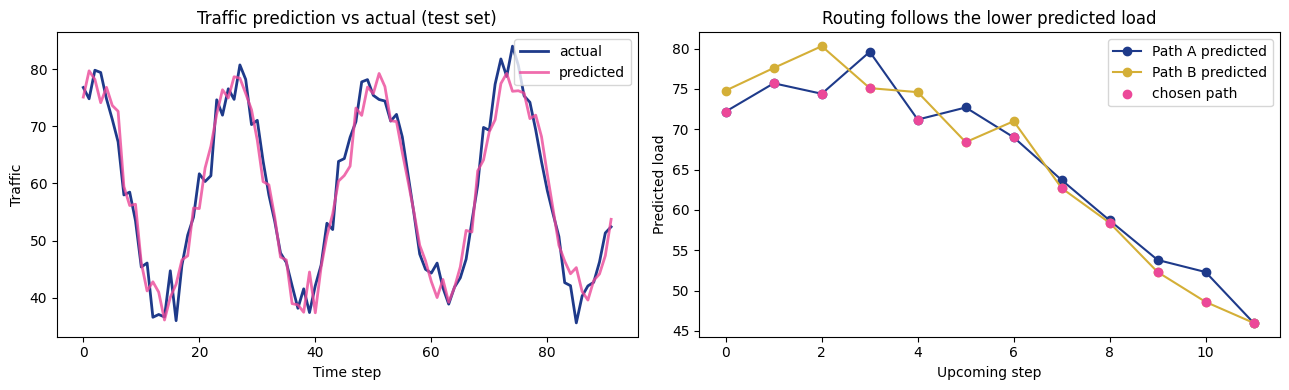

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def make_traffic(n=480, base=50, amp=20, trend=0.02, seed=0):
    """Synthetic traffic with a daily cycle, a slow upward trend, and noise."""
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    series = base + amp * np.sin(2 * np.pi * t / 24) + trend * t + rng.normal(0, 3, n)
    return np.clip(series, 0, None)

def add_lags(series):
    """Turn a series into a table whose features are only PAST values (no leakage)."""
    d = pd.DataFrame({"traffic": series})
    for lag in [1, 2, 3, 24]:
        d[f"lag_{lag}"] = d["traffic"].shift(lag)
    return d.dropna().reset_index(drop=True)

FEATURES = ["lag_1", "lag_2", "lag_3", "lag_24"]

# Train a model to predict traffic from its recent history
traffic = make_traffic(seed=1)
df = add_lags(traffic)
split = int(len(df) * 0.8)                       # time-ordered split, no shuffling
X_train, X_test = df[FEATURES].iloc[:split], df[FEATURES].iloc[split:]
y_train, y_test = df["traffic"].iloc[:split], df["traffic"].iloc[split:]

reg = LinearRegression().fit(X_train, y_train)
pred = reg.predict(X_test)
print("Traffic prediction on held-out data:")
print(f"  MAE  : {mean_absolute_error(y_test, pred):.2f}")
print(f"  RMSE : {mean_squared_error(y_test, pred) ** 0.5:.2f}")
print(f"  R2   : {r2_score(y_test, pred):.3f}")

# Use the forecast to steer routing across two paths.
# For each upcoming step I predict both paths' load and send the new flow to the quieter one.
pathA, pathB = make_traffic(seed=11), make_traffic(seed=22)
dA, dB = add_lags(pathA), add_lags(pathB)
modelA = LinearRegression().fit(dA[FEATURES].iloc[:split], dA["traffic"].iloc[:split])
modelB = LinearRegression().fit(dB[FEATURES].iloc[:split], dB["traffic"].iloc[:split])

decisions = []
for i in range(split, split + 12):
    predA = modelA.predict(dA[FEATURES].iloc[[i]])[0]
    predB = modelB.predict(dB[FEATURES].iloc[[i]])[0]
    decisions.append({"predicted A": round(predA, 1), "predicted B": round(predB, 1),
                      "route to": "Path A" if predA <= predB else "Path B"})
decision_table = pd.DataFrame(decisions)
print("\nPredictive routing (send the flow to the quieter predicted path):")
print(decision_table.to_string(index=False))

# Plot predicted vs actual, and the routing choices
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(y_test.values, color="#1e3a8a", label="actual", linewidth=2)
ax[0].plot(pred, color="#ec4899", label="predicted", linewidth=2, alpha=0.8)
ax[0].set_title("Traffic prediction vs actual (test set)")
ax[0].set_xlabel("Time step"); ax[0].set_ylabel("Traffic"); ax[0].legend()

x = range(len(decision_table))
ax[1].plot(x, decision_table["predicted A"], color="#1e3a8a", marker="o", label="Path A predicted")
ax[1].plot(x, decision_table["predicted B"], color="#d4af37", marker="o", label="Path B predicted")
chosen_low = [min(a, b) for a, b in zip(decision_table["predicted A"], decision_table["predicted B"])]
ax[1].scatter(x, chosen_low, color="#ec4899", zorder=5, label="chosen path")
ax[1].set_title("Routing follows the lower predicted load")
ax[1].set_xlabel("Upcoming step"); ax[1].set_ylabel("Predicted load"); ax[1].legend()
plt.tight_layout()
plt.show()

**What this shows.** The model tracks the real traffic closely on data it never trained on, so the forecast is trustworthy enough to act on. The routing step then puts that forecast to work: at each upcoming step it compares the two paths' predicted loads and sends the flow to the quieter one, which spreads traffic before congestion has a chance to form. This is the self-optimizing idea from the course, an AI prediction feeding back into a control decision, and it matches the outcomes for this part: combining AI and simulation for network self-optimization, and applying a regression model for predictive traffic control.

## Summary

The three parts move from watching a network to steering it. SimPy showed how queueing turns into latency and set a throughput number for a fixed chain. Mesa let the routers respond on their own, so congestion built and then cleared as traffic was rerouted to neighbors. The machine learning part closed the loop by predicting traffic and using that prediction to route flows before congestion formed. Together they cover the three tools the midterm asked for, discrete-event simulation, agent-based modeling, and predictive machine learning, applied to the same problem of keeping traffic moving through a network.